In [9]:
%reload_ext autoreload
%autoreload 2

In [10]:
from probjax.utils.stats import betaincinv, differential_entropy, gammaincinv, _compute_initial_guess_gammaincinv
from scipy.special import gammaincinv as scipy_gammaincinv
from scipy.special import gammainc as scipy_gammainc

import jax 
from jax.scipy.special import gammainc
import jax.numpy as jnp

import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)
jax.config.update("jax_platform_name", "cpu")

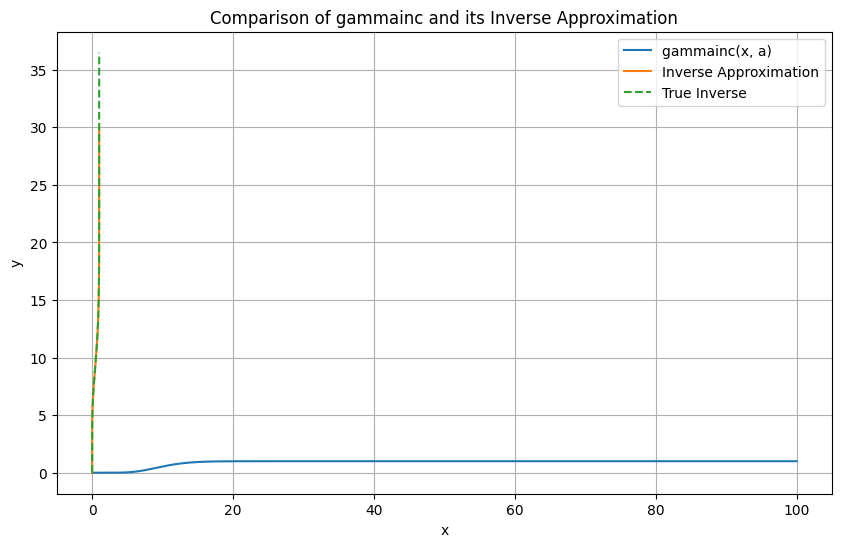

In [11]:
x = jnp.linspace(0., 100, 1000)
a = 10.
y = gammainc(a,x)
x_rec = gammaincinv(a,y)
true_inverse = scipy_gammaincinv(a, y)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='gammainc(x, a)')
plt.plot(y, x_rec, label='Inverse Approximation')
plt.plot(y, true_inverse, label='True Inverse', linestyle='--')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparison of gammainc and its Inverse Approximation')
plt.grid(True)
plt.show()


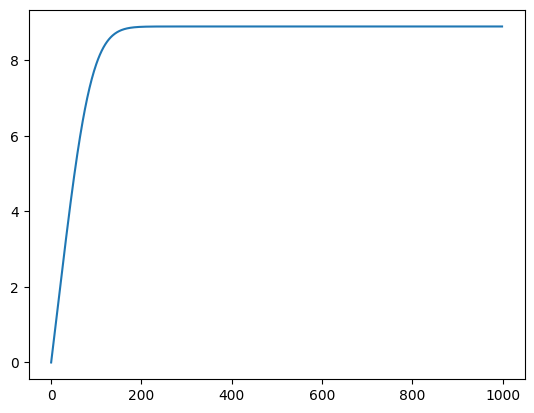

In [7]:
plt.plot(_compute_initial_guess_gammaincinv(a, y))

In [8]:
#%%timeit
x_rec = gammaincinv(a,y)

In [9]:
#%%timeit 
x_rec2 = scipy_gammaincinv(a, y)

In [10]:
jnp.allclose(x_rec, x_rec2, atol=1e-1)

Array(False, dtype=bool)

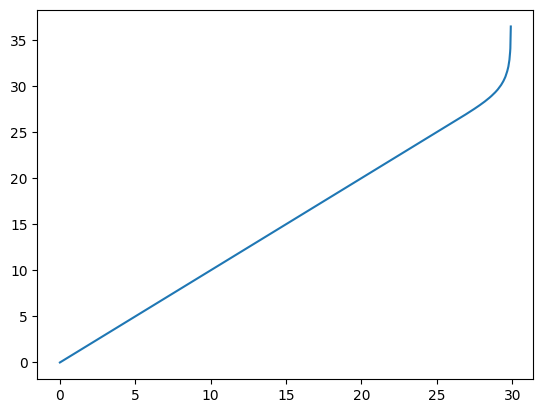

In [11]:
plt.plot(x_rec, x_rec2)

In [12]:
import numpy as np
from scipy.special import gamma, gammainc, erfcinv
import matplotlib.pyplot as plt


def initial_approx_small_p(p, a):
    """
    Compute the initial approximation of the inverse incomplete gamma function
    for small values of p using the asymptotic series expansion.

    Parameters:
    p : float
        The value of the regularized incomplete gamma function (0 <= p <= 1).
    a : float
        The shape parameter of the gamma function (a > 0).

    Returns:
    x : float
        The initial approximation of the inverse incomplete gamma function.
    """

    # Compute r as the initial approximation
    r = (p * gamma(1 + a)) ** (1 / a)

    # Coefficients for the series expansion
    c2 = 1 / (a + 1)
    c3 = (3 * a + 5) / (2 * (a + 1) ** 2 * (a + 2))
    c4 = (8 * a**2 + 33 * a + 31) / (3 * (a + 1) ** 3 * (a + 2) * (a + 3))
    c5 = (125 * a**4 + 1179 * a**3 + 3971 * a**2 + 5661 * a + 2888) / (
        24 * (a + 1) ** 4 * (a + 2) ** 2 * (a + 3) * (a + 4)
    )

    # Initial approximation using the first few terms of the series
    x = r + c2 * r**2 + c3 * r**3 + c4 * r**4 + c5 * r**5

    return x


def initial_approx_large_p(p, a):
    q = 1 - p
    x = compute_x_small_q(q, a)
    return x


def compute_x_small_q(q, a):
    """
    Computes the value of x for small q using the asymptotic expansion.

    Parameters:
        q (float): Small value of q.
        a (float): Parameter a.

    Note: q < e−0.5a /Γ(a + 1) fra a < 10

    Returns:
        float: Approximation of x.
    """

    # Initial approximation x0
    x0 = -np.log(q * gamma(a))  # Derived from e^{-x0} x0^a = qΓ(a)

    b = 1 - a
    L = np.log(x0)

    # Compute higher order corrections
    d1 = L - 1
    d2 = (3 * b - 2 * b * L + L**2 - 2 * L + 2) / 2
    d3 = (
        24 * b * L
        - 11 * b**2
        - 24 * b
        - 6 * L**2
        + 12 * L
        - 12
        - 9 * b * L**2
        + 6 * b**2 * L
        + 2 * L**3
    ) / 6
    d4 = (
        72
        + 36 * L**2
        + 3 * L**4
        - 72 * L
        + 162 * b
        - 168 * b * L
        - 12 * L**3
        + 25 * b**3
        - 22 * b * L**3
        + 36 * b**2 * L**2
        - 12 * b**3 * L
        + 84 * b * L**2
        + 120 * b**2
        - 114 * b**2 * L
    ) / 12

    x = x0 - L + b * (d1 / x0 + d2 / x0**2 + d3 / x0**3 + d4 / x0**4)
    return x


def bracket_x(p, a):
    # Lower bound is valid
    # Upper bound only for a < 1

    gamma_a1 = gamma(a + 1)
    denom = np.where(a < 1, a, a - 1)
    x_l = (p * gamma_a1) ** (1 / denom)

    # Upper bound with stability refinement for p -> 1
    cond = p * gamma_a1 > 1.0
    x_u = np.where(cond, -np.log(1 - p * gamma_a1), a - 1 + np.log(gamma(a) / (1 - p)))

    return x_l, x_u

def bracket_gamma_inverse(p, a):
    """
    Return lower- and upper-bracket xL, xU such that:
        gammainc(a, xL) <= p*gammainc(a, np.inf)  (i.e. P(a, xL) <= p)
        gammainc(a, xU) >= p*gammainc(a, np.inf)  (i.e. P(a, xU) >= p)
    for a in (0,1).
    """
    # 1) LOWER BOUND
    #    Using incGamma(a, x) ~ x^a / a for small x => P(a, x) ~ x^a / Gamma(a+1).
    #    So xL = ( p * Gamma(a+1) )^(1/a).
    #    Optionally "safety factor" for p near 1:
    gamma_a1 = gamma(a + 1)
    denom = np.where(a < 1, a, a - 1)
    x_l = (p * gamma_a1) ** (1 / denom)

    # 2) UPPER BOUND
    #    We can do an asymptotic-based guess: xU = (a - 1) + ln(Gamma(a)/(1-p)).
    #    Then *verify* it actually brackets. If it doesn't, we'll bump it up.
    #    However, if p is extremely small, that log might be large negative. So we
    #    do a piecewise approach:
    with np.errstate(divide='ignore', invalid='ignore'):
        # Start with an "asymptotic" guess if p is not too small:
        # We'll clamp p to avoid log(0) or negative arguments.
        p_clip = np.maximum(1e-15, np.minimum(1.0 - 1e-15, p))
        x_u_guess = (a - 1.0) + np.log(gamma(a)/(1.0 - p_clip))

    # If that guess is below x_l, or not finite, pick something bigger than x_l:
    x_u = np.maximum(x_u_guess, x_l + 1.0)


    # # If some calls might be vector, we'd do it with a loop or so.
    # # For now assume p is scalar in this snippet:
    y_u = gammainc(a, x_u)
    x_u = np.where(y_u < p, x_u*1.5, x_u)
    # MAX_STEPS = 2
    # step = 0
    # while step < MAX_STEPS:
    #     x_u *= 2.0
    #     step += 1

    return x_l, x_u


In [13]:

def _initial_approx_small_p(p, a):
    """
    Compute the initial approximation of the inverse incomplete gamma function
    for small values of p using the asymptotic series expansion.

    Parameters:
    p : float
        The value of the regularized incomplete gamma function (0 <= p <= 1).
    a : float
        The shape parameter of the gamma function (a > 0).

    Returns:
    x : float
        The initial approximation of the inverse incomplete gamma function.
    """

    # Compute r as the initial approximation
    r = (p * jax.scipy.special.gamma(1 + a)) ** (1 / a)

    # Coefficients for the series expansion
    c2 = 1 / (a + 1)
    c3 = (3 * a + 5) / (2 * (a + 1) ** 2 * (a + 2))
    c4 = (8 * a**2 + 33 * a + 31) / (3 * (a + 1) ** 3 * (a + 2) * (a + 3))
    c5 = (125 * a**4 + 1179 * a**3 + 3971 * a**2 + 5661 * a + 2888) / (
        24 * (a + 1) ** 4 * (a + 2) ** 2 * (a + 3) * (a + 4)
    )

    # Initial approximation using the first few terms of the series
    x = r + c2 * r**2 + c3 * r**3 + c4 * r**4 + c5 * r**5

    return x


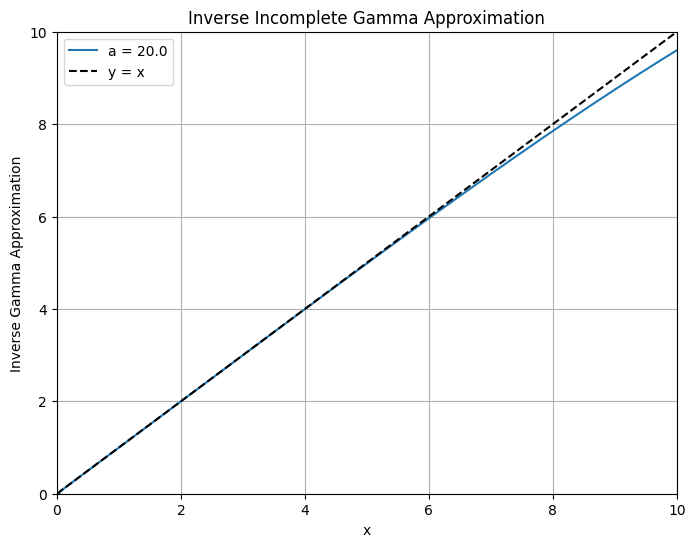

In [14]:
# Example usage


plt.figure(figsize=(8, 6))
for a in [20.]:
    x = np.linspace(0, a + 3*jnp.sqrt(a) , 1000)
    p = gammainc(a, x)
    x_approx = _initial_approx_small_p(p, a)
    #x_approx = initial_approx_large_p(p, a)
    plt.plot(x, x_approx, label=f"a = {a}")

plt.plot(x, x, label="y = x", linestyle="--", color="black")
plt.xlabel("x")
plt.xlim(0,10)
plt.ylim(0,10)
plt.ylabel("Inverse Gamma Approximation")
plt.title("Inverse Incomplete Gamma Approximation")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
a

20.0

In [16]:
a = 3.
-np.log(0.1 * gamma(a)) 



np.float64(1.6094379124341003)

/tmp/ipykernel_13489/2064943524.py:23: RuntimeWarning: divide by zero encountered in divide
  r = (p * gamma(1 + a)) ** (1 / a)


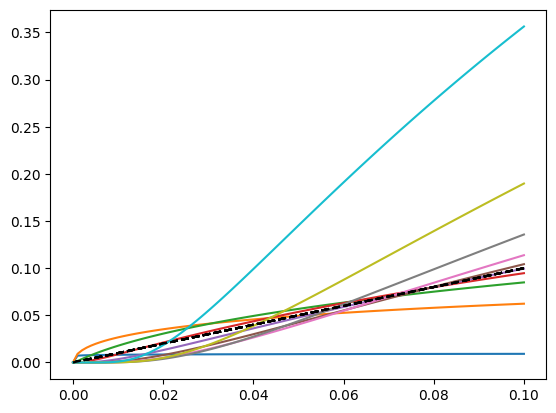

In [17]:

for a in np.linspace(0.01, 0.9, 10):
    #x = np.linspace(0, a + 3*a, 1000)
    x = np.linspace(0, 0.1, 100)
    p = gammainc(a, x)
    plt.plot(x, initial_approx_small_p(a, p))
    
    plt.plot(x,x, linestyle='--', color='black')

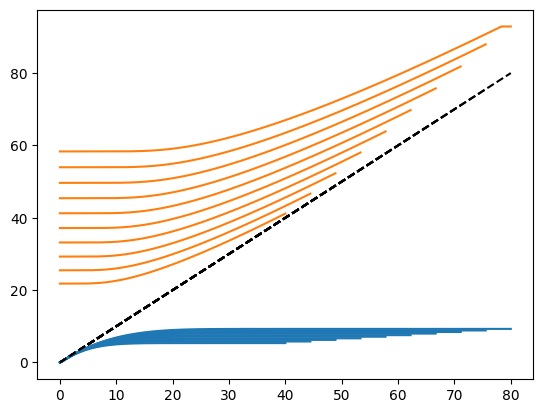

In [18]:
# Example usage
for a in np.linspace(10, 20, 10):
    x = np.linspace(0, a + 3*a, 1000)
    p = gammainc(a, x)
    x_l, x_u = bracket_gamma_inverse(p, a)


    plt.plot(x,x_l, color="C0")
    plt.plot(x,x_u, color="C1")
    plt.plot(x,x, linestyle='--', color='black')

assert jnp.all(x_l <= x)
assert jnp.all(x_u >= x)


In [19]:
x_l

array([0.        , 0.06983484, 0.14427896, 0.22020121, 0.29688753,
       0.37399053, 0.45130246, 0.52868469, 0.60603811, 0.68328842,
       0.76037797, 0.83726084, 0.91389971, 0.99026376, 1.06632719,
       1.14206819, 1.21746813, 1.29251103, 1.36718305, 1.44147219,
       1.51536797, 1.58886125, 1.661944  , 1.73460918, 1.80685061,
       1.87866285, 1.95004115, 2.02098133, 2.09147973, 2.16153319,
       2.23113894, 2.30029461, 2.36899817, 2.4372479 , 2.50504237,
       2.57238041, 2.63926108, 2.70568366, 2.77164763, 2.83715265,
       2.90219857, 2.96678536, 3.03091316, 3.09458223, 3.15779297,
       3.22054589, 3.28284159, 3.34468078, 3.40606428, 3.46699296,
       3.5274678 , 3.58748985, 3.64706022, 3.7061801 , 3.76485072,
       3.82307338, 3.88084945, 3.93818032, 3.99506745, 4.05151232,
       4.10751649, 4.16308152, 4.21820903, 4.27290066, 4.32715809,
       4.38098304, 4.43437723, 4.48734244, 4.53988044, 4.59199306,
       4.64368213, 4.69494949, 4.74579702, 4.79622662, 4.84624

In [20]:
from probjax.utils.stats import _initial_approx_small_p

In [21]:

def _initial_approx_small_p(p, a):
    """
    Compute the initial approximation of the inverse incomplete gamma function
    for small values of p using the asymptotic series expansion.

    Parameters:
    p : float
        The value of the regularized incomplete gamma function (0 <= p <= 1).
    a : float
        The shape parameter of the gamma function (a > 0).

    Returns:
    x : float
        The initial approximation of the inverse incomplete gamma function.
    """

    # Compute r as the initial approximation
    r = (p * jax.scipy.special.gamma(1 + a)) ** (1 / a)

    # Coefficients for the series expansion
    c2 = 1 / (a + 1)
    c3 = (3 * a + 5) / (2 * (a + 1) ** 2 * (a + 2))
    c4 = (8 * a**2 + 33 * a + 31) / (3 * (a + 1) ** 3 * (a + 2) * (a + 3))
    c5 = (125 * a**4 + 1179 * a**3 + 3971 * a**2 + 5661 * a + 2888) / (
        24 * (a + 1) ** 4 * (a + 2) ** 2 * (a + 3) * (a + 4)
    )

    # Initial approximation using the first few terms of the series
    x = r + c2 * r**2 + c3 * r**3 + c4 * r**4 + c5 * r**5

    return x


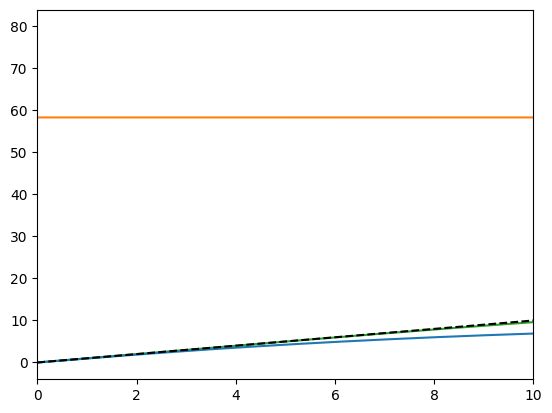

In [22]:
from probjax.utils.stats import _compute_initial_guess_gammaincinv, _bracket_gamma_inverse
for a in [20.]:
    x = jnp.linspace(0, a + 3*a, 1000)
    x0 = _compute_initial_guess_gammaincinv(a, p)
    xl, xu = _bracket_gamma_inverse(a,p)
    p = gammainc(a, x)
    
    
    plt.plot(x, x0, color="C2")
    plt.plot(x, xl, color="C0")
    plt.plot(x, xu, color="C1")
    plt.xlim(0,10)
    
    plt.plot(x,x, linestyle='--', color='black')
    
    
    assert jnp.all(xl <= x)

In [23]:
%reload_ext autoreload
%autoreload 2

In [24]:
from probjax.utils.stats import _compute_initial_guess_gammaincinv, _bracket_gamma_inverse, gammaincinv, _initial_approx_small_p

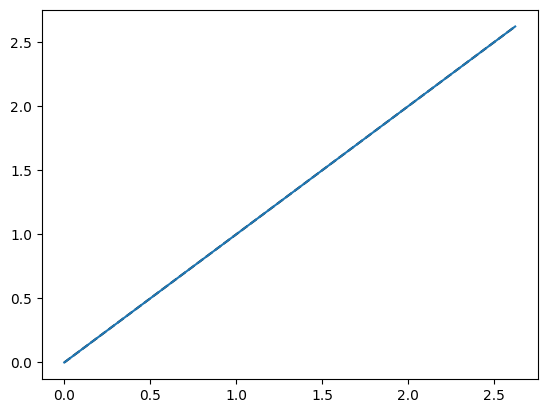

In [3]:
a= 0.5
x = jnp.linspace(jnp.maximum(0, a - 3*jnp.sqrt(a)), a + 3 * jnp.sqrt(a), 1000)
p = gammainc(a, x)

# Calculate x-values using your gammaincinv function
x_rec = gammaincinv(a, p)
x_scipy = scipy_gammaincinv(a, p)
x_rec_init = _compute_initial_guess_gammaincinv(a, p)


plt.plot(x,x, linestyle='--', color='black')
plt.plot(x_rec, x_scipy, label='Inverse Approximation')
#plt.plot(x_rec_init, x_scipy, label='Initial Approximation')

In [4]:
from jax.scipy.special import gammainc
jax.config.com
jax.jit(_compute_initial_guess_gammaincinv)(a, gammainc(a, jnp.array(3)))

AttributeError: 'Config' object has no attribute 'com'

In [5]:
a = 0.5

with jax.disable_jit():
    gammaincinv(a, gammainc(a,jnp.array([0.5])))

In [7]:
%%timeit 
gammaincinv(0.5, 0.5)

44.6 μs ± 3.31 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
